<img src="slides/slide-01-title.png" style="width:100%;height:auto;display:block;border-radius:8px;box-shadow:0 1px 12px rgba(0,0,0,0.32);margin:0.6em 0;" alt="slide-01-title.png" />

**Live · Quantum Club Thailand · True Digital Park · 3 August 2026 · QTRiC × qBraid**

## 0 · Setup

In [1]:
import sys, os, json, time, math, warnings, inspect
warnings.filterwarnings("ignore")
sys.path.insert(0, os.getcwd())          # make the local modules importable on Lab

import nbsetup
nbsetup.ensure_environment()             # install anything missing on a fresh kernel

import numpy as np, pandas as pd, networkx as nx
import sleepcells as sc                   # tested pipeline + printed reports (single source of truth)
import sleepviz as viz                    # all matplotlib figures live here

try:
    import qbraid; QBRAID_VER = qbraid.__version__
except Exception:
    QBRAID_VER = "not importable"
print(f"qbraid {QBRAID_VER} · numpy {np.__version__} · networkx {nx.__version__}")

environment ready — all packages present


qbraid 0.12.3.dev · numpy 2.4.6 · networkx 3.6.1


In [2]:
# --- TOP-OF-NOTEBOOK PARAMETERS (the knobs) ---------------------------------
COVERAGE_OVERLAP_M = sc.COVERAGE_OVERLAP_M   # 500 m: two sites "mutually cover" within this distance
HEADLINE_ATOMS   = 90     # headline sub-district size (largest that fits Aquila's field on real data)
LIVE_ATOMS       = 16     # atoms in the live audience instance
SUBMIT_LIVE_JOB  = False  # True submits the live job to Aquila; False uses committed results
LIVE_SHOTS       = 100    # shots for the live job (maximum 1000)

DATA_CSV    = "data/watthana_cells_real.csv"    # REAL OpenCelliD extract (True-group, MCC 520)
RESULTS_DIR = "results"
CENTER      = (13.731, 100.575)              # Watthana / Sukhumvit centre (WGS84)

viz.apply_style()
print(f"COVERAGE_OVERLAP_M = {COVERAGE_OVERLAP_M:.0f} m   HEADLINE_ATOMS = {HEADLINE_ATOMS}   "
      f"LIVE_ATOMS = {LIVE_ATOMS}   SUBMIT_LIVE_JOB = {SUBMIT_LIVE_JOB}")

COVERAGE_OVERLAP_M = 500 m   HEADLINE_ATOMS = 90   LIVE_ATOMS = 16   SUBMIT_LIVE_JOB = False


In [3]:
# --- device resolution: ENUMERATE, do not hardcode ARNs (read-only; no job sent) ---
provider = None
DEVICE_ID = sc.AQUILA_DEVICE_ID          # 'aws:quera:qpu:aquila' (confirmed live on qBraid)
try:
    from qbraid.runtime import QbraidProvider
    provider = QbraidProvider()
    online = [d.id for d in provider.get_devices()]
    aq = provider.get_device(DEVICE_ID)
    md_aq = aq.metadata()
    print(f"Aquila resolved  : {DEVICE_ID}")
    print(f"  status         : {md_aq.get('status')}")
    print(f"  qubits         : {md_aq.get('num_qubits')}   (up to 256 ⁸⁷Rb atoms)")
    print(f"  program type   : braket_ahs   ·   shots ≤ {sc.AQUILA_SHOTS_MAX}")
    pr = md_aq.get('pricing', {})
    print(f"  pricing        : {pr.get('perTask')} credits/task + {pr.get('perShot')} credit/shot")
    print(f"  analog devices online: {[x for x in online if 'aquila' in x or 'fresnel' in x]}")
except Exception as e:
    print("qBraid provider unavailable — running FULLY OFFLINE from committed files.")
    print("  reason:", repr(e)[:120])

Aquila resolved  : aws:quera:qpu:aquila
  status         : ONLINE
  qubits         : 256   (up to 256 ⁸⁷Rb atoms)
  program type   : braket_ahs   ·   shots ≤ 1000
  pricing        : 30.0 credits/task + 1.0 credit/shot
  analog devices online: ['aws:quera:qpu:aquila', 'azure:pasqal:qpu:fresnel']


## 1 · Submit the live job to Boston

In [4]:
# Build the live instance (same pipeline as everything else) and the AHS program.
live_inst = sc.load_instance(f"{RESULTS_DIR}/sukhumvit_{LIVE_ATOMS}.json")
live_reg  = sc.register_from_instance(live_inst)
live_G    = live_inst["graph"]
live_ahs  = sc.build_ahs_program(live_reg)      # coordinates in METRES, Ω starts/ends at 0

live_job, live_task_id = None, None
cost = sc.task_credits(LIVE_SHOTS)
print(f"Live instance    : {LIVE_ATOMS} atoms, {live_G.number_of_edges()} coverage edges")
print(f"AHS program      : 4 µs quasi-adiabatic sweep, {LIVE_SHOTS} shots  (cost {cost} credits)")

if SUBMIT_LIVE_JOB:
    try:
        live_job = aq.run(live_ahs, shots=LIVE_SHOTS)          # <-- the only line that submits
        live_task_id = getattr(live_job, "id", None) or str(live_job)
        print(f"\nSubmitted. Task ID: {live_task_id}")
    except Exception as e:
        print("\nSubmission unavailable (device offline or queue closed):", repr(e)[:160])
else:
    print("\nSUBMIT_LIVE_JOB is False — running from committed results; no job submitted.")

Live instance    : 16 atoms, 32 coverage edges
AHS program      : 4 µs quasi-adiabatic sweep, 100 shots  (cost 130 credits)

SUBMIT_LIVE_JOB is False — running from committed results; no job submitted.


## 2 · Ten towers, one question

<img src="slides/slide-02-ten-towers.png" style="width:100%;height:auto;display:block;border-radius:8px;box-shadow:0 1px 12px rgba(0,0,0,0.32);margin:0.6em 0;" alt="slide-02-ten-towers.png" />

**Which cell towers can we switch off at 3 a.m. — so more people, more sleep for the network —
without opening a coverage hole?**

## 3 · This question already has a name

<img src="slides/slide-03-formulation.png" style="width:100%;height:auto;display:block;border-radius:8px;box-shadow:0 1px 12px rgba(0,0,0,0.32);margin:0.6em 0;" alt="slide-03-formulation.png" />

It is **Maximum Independent Set**: the largest set of towers no two of which have overlapping
coverage — the most cells that can sleep at once with every metre still covered.

## 4 · WHY — at 3 a.m. the network is awake, almost nobody is

<img src="slides/slide-05-problem.png" style="width:100%;height:auto;display:block;border-radius:8px;box-shadow:0 1px 12px rgba(0,0,0,0.32);margin:0.6em 0;" alt="slide-05-problem.png" />

<img src="slides/slide-06-why-now.png" style="width:100%;height:auto;display:block;border-radius:8px;box-shadow:0 1px 12px rgba(0,0,0,0.32);margin:0.6em 0;" alt="slide-06-why-now.png" />

<img src="slides/slide-07-blocker.png" style="width:100%;height:auto;display:block;border-radius:8px;box-shadow:0 1px 12px rgba(0,0,0,0.32);margin:0.6em 0;" alt="slide-07-blocker.png" />

## 5 · Assumptions

<img src="slides/slide-13-assumptions.png" style="width:100%;height:auto;display:block;border-radius:8px;box-shadow:0 1px 12px rgba(0,0,0,0.32);margin:0.6em 0;" alt="slide-13-assumptions.png" />

In [5]:
sc.print_assumptions()

ASSUMPTIONS  ·  'Which cells can sleep tonight?'
SCALE MAPPING (nothing tuned to flatter the hardware):
  coverage overlap           500 m   <-> blockade radius 8.4 µm
  scale factor              59.5 m per µm
  min site merge distance    238 m   <-> min atom spacing 4.0 µm
  field of view             4.46 km  <-> 75.0 µm (narrower than a human hair)
  → 4.5 km of Sukhumvit, rendered in an area narrower than a hair. We did NOT tune
    the blockade radius to match — that is where rubidium happens to sit.
--------------------------------------------------------------------------
ASSUMPTIONS (flagged where not a measured or published constant):
  [assumed] site power         4.0 kW      — largest lever on the money model
            radio share        60%        — rest is cooling / baseband / transmission
            deep-sleep saving  70%        — Vodafone UK + Ericsson, London 2025
  [assumed] low-traffic window  6.0 h     — night window (not a 3GPP constant)
            tariff        

## 6 · Load Sukhumvit and build the coverage graph

*Cell-tower positions are a real OpenCelliD extract — crowdsourced estimates, not surveyed
towers (data © OpenCelliD, CC-BY-SA 4.0). Only **LTE/UMTS** are sleep candidates; GSM stays
awake as the 2G coverage floor.*

In [6]:
# Load -> filter (True MNCs, MCC 520) -> cluster cells to sites -> merge to atoms
df = sc.load_cells(DATA_CSV)
fdf = sc.filter_cells(df)
sites = sc.cluster_cells_to_sites(fdf, CENTER[0], CENTER[1], radius_m=50.0)
atoms = sc.merge_close_sites(sites)

sc.print_merge_counts(sites, atoms, fdf)     # fdf = the True-group LTE/UMTS cells actually used

SITE-MERGE COUNTS (printed explicitly):
  3401 cells  ->   851 sites  ->   116 atoms
  radio mix : {'UMTS': 2130, 'LTE': 1271}
  True MNCs : [0, 4, 5, 18, 99]   (MCC 520)
  after merge, closest two atoms are 240 m apart (floor 238 m)


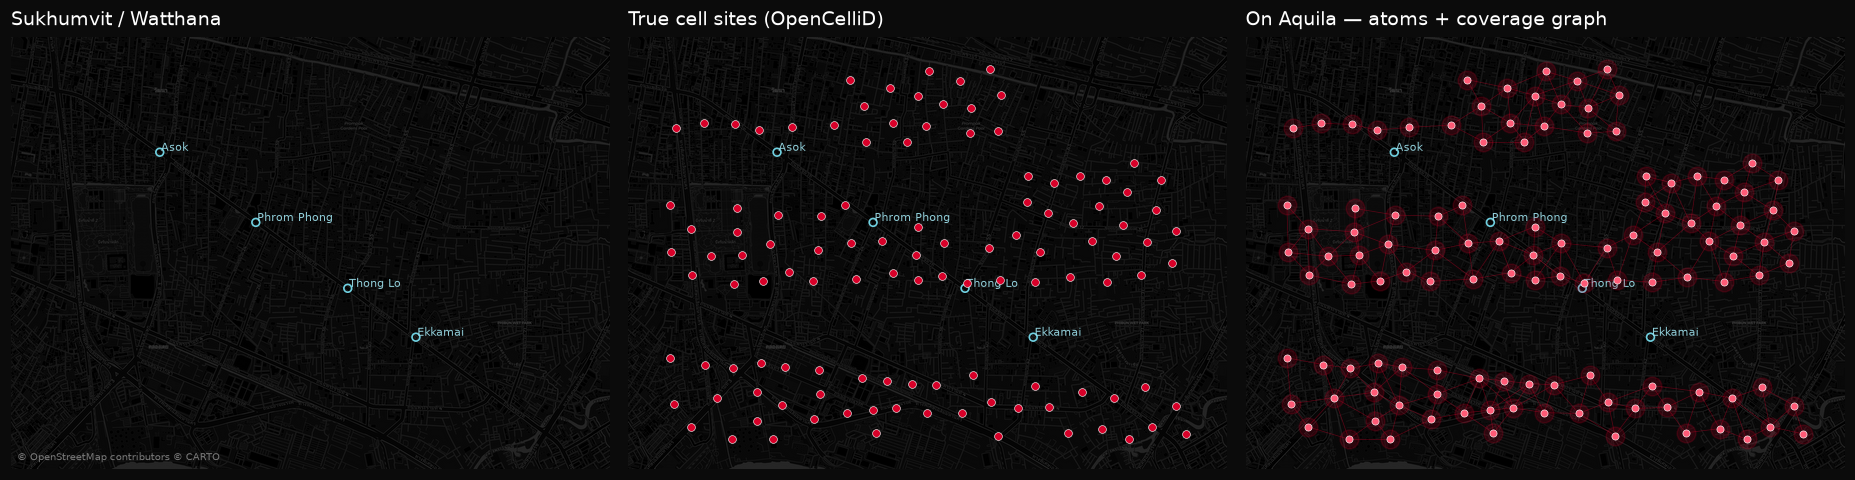

In [7]:
# The REAL Sukhumvit map: the region, the True cell towers on it, then the atoms and the
# coverage graph — the same shape we hand to Aquila.
map_edges = list(sc.build_graph(atoms).edges())     # geographic 500 m coverage graph
viz.sukhumvit_map_layers("data/sukhumvit_basemap.png", "data/sukhumvit_basemap.json",
                         atoms.lon, atoms.lat, map_edges)

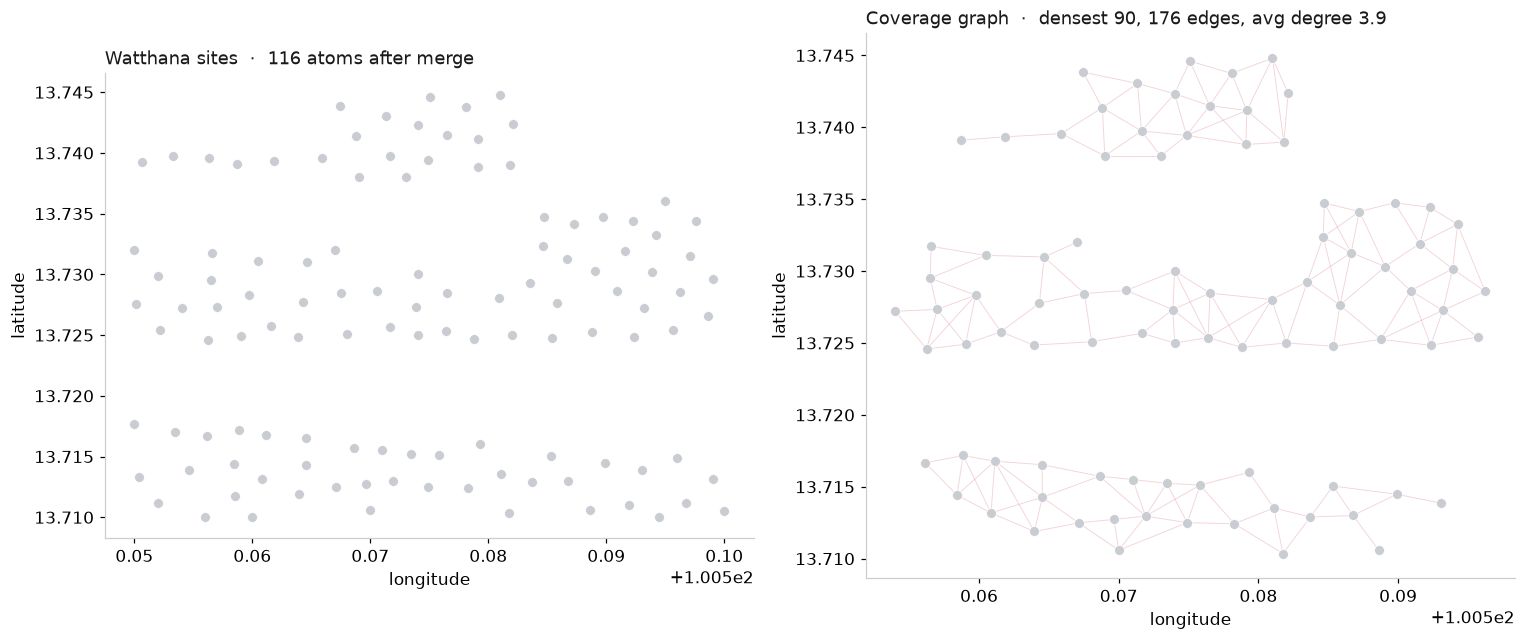

In [8]:
# The same, abstractly: the full district and the coverage graph on the densest sub-district
# we run — built from the ACTUAL atom register (snapped to Aquila's rows).
subH = sc.select_densest(atoms, HEADLINE_ATOMS)
regH = sc.affine_to_atoms(subH)
edgesH = list(sc.build_graph_from_register(regH).edges())
viz.district_and_graph(atoms, subH, edgesH)

## 7 · AUDIENCE — run it yourself

In [9]:
t0 = time.time()
try:
    from braket.devices import LocalSimulator
    res_live = LocalSimulator("braket_ahs").run(
        live_ahs, shots=200, blockade_radius=sc.BLOCKADE_RADIUS_UM * 1e-6, steps=100
    ).result()
    shots_live = [sc.Shot(m.pre_sequence, m.post_sequence) for m in res_live.measurements]
    live_source = "LOCAL SIMULATOR (run just now)"
except Exception as e:
    print("local simulator unavailable, loading committed result:", repr(e)[:80])
    rres = sc.load_results(f"{RESULTS_DIR}/localsim_{LIVE_ATOMS}_results.json")
    shots_live = rres["shots"]; live_source = "committed local-simulator result"

sel_live, ret, tot, defect = sc.decode_shots(shots_live, live_inst["n_atoms"])
sim_best = max(sel_live, key=len)
exact_live = live_inst["classical"]["exact_size"]
dt = time.time() - t0

print(f"quantum method   : {live_source}")
print(f"  best independent set over {ret}/{tot} shots : |S| = {len(sim_best)}")
print(f"exact classical  : max_weight_clique on complement -> optimum = {exact_live}")
print(f"coverage check   : {'COVERAGE VERIFIED' if sc.verify_independent_set(live_G, sim_best) else 'FAILED'}")
print(f"approximation    : {len(sim_best)}/{exact_live} = {len(sim_best)/exact_live:.2f}")
print(f"\nwall-clock       : {dt:.1f} s   (target < 60 s)")

quantum method   : LOCAL SIMULATOR (run just now)
  best independent set over 200/200 shots : |S| = 7
exact classical  : max_weight_clique on complement -> optimum = 7
coverage check   : COVERAGE VERIFIED
approximation    : 7/7 = 1.00

wall-clock       : 3.5 s   (target < 60 s)


## 8 · HOW — that shape is also the shape of the machine

<img src="slides/slide-04-mapping.png" style="width:100%;height:auto;display:block;border-radius:8px;box-shadow:0 1px 12px rgba(0,0,0,0.32);margin:0.6em 0;" alt="slide-04-mapping.png" />

In [10]:
# The scale table — Sukhumvit rendered on the chip
sc.print_scale_table()

# Aquila's bit semantics are inverted; reading them backwards silently flips the answer,
# so the selection rule is stated explicitly:
print("\nSelection rule (Rydberg bit semantics are inverted):\n")
print(inspect.getsource(sc.rydberg_selected))

quantity                              chip         network
----------------------------------------------------------
blockade radius / overlap            8.4 µm          500 m
min atom spacing / merge             4.0 µm          238 m
field of view                       75.0 µm       4.46 km
scale factor                                     59.5 m/µm

Selection rule (Rydberg bit semantics are inverted):

def rydberg_selected(pre_sequence: Sequence[int], post_sequence: Sequence[int]) -> list[int]:
    """Return the indices of atoms that are IN the independent set (cells that sleep).

    Aquila result bit semantics are INVERTED from intuition:
      pre_sequence[k]:  0 = trap empty,           1 = atom loaded
      post_sequence[k]: 0 = Rydberg OR site empty, 1 = ground state
    An atom is excited to Rydberg (i.e. selected into the independent set) iff it
    was loaded AND ended up NOT in the ground state:
        selected  <=>  pre[k] == 1 and post[k] == 0
    """
    return [k for k 

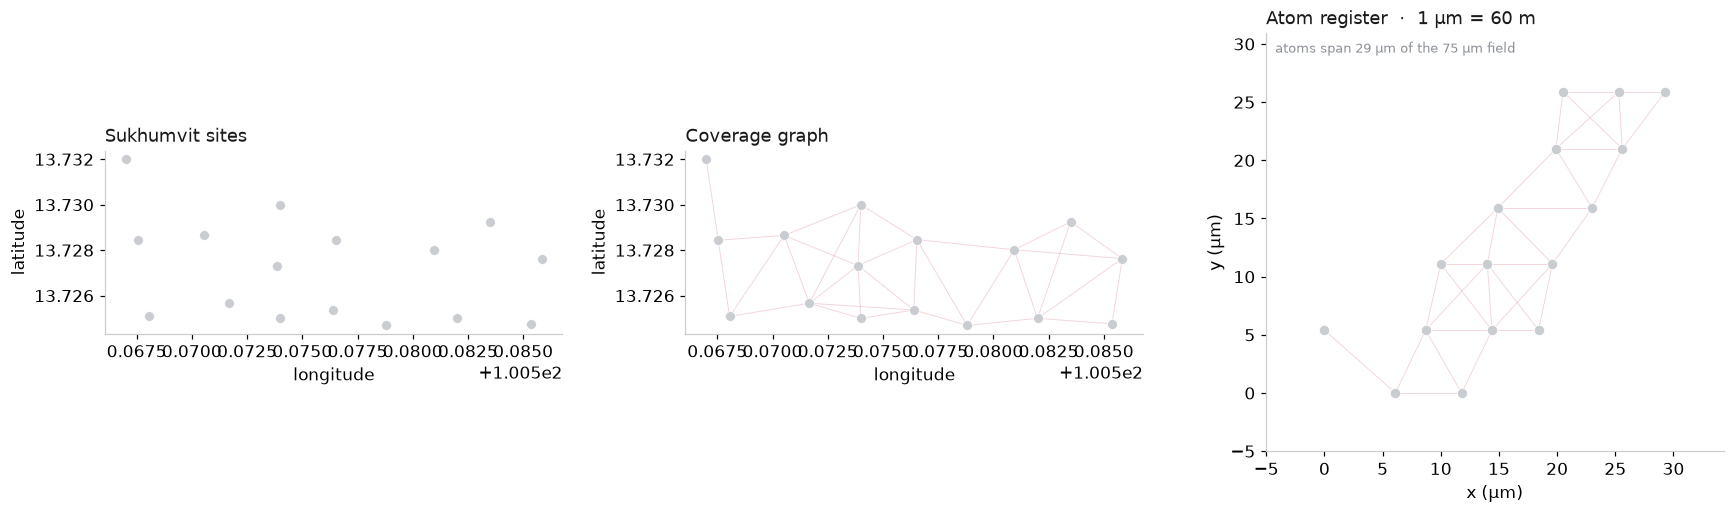

In [11]:
# Three-panel "same shape" figure on the live instance: sites | graph | atom register
viz.three_panel(live_inst, live_reg, live_G)

## 9 · RESULT 1 — Sukhumvit on the headline instance

<img src="slides/slide-08-experiment.png" style="width:100%;height:auto;display:block;border-radius:8px;box-shadow:0 1px 12px rgba(0,0,0,0.32);margin:0.6em 0;" alt="slide-08-experiment.png" />

<img src="slides/slide-09-result.png" style="width:100%;height:auto;display:block;border-radius:8px;box-shadow:0 1px 12px rgba(0,0,0,0.32);margin:0.6em 0;" alt="slide-09-result.png" />

In [12]:
# Load the pre-run instance + results; the banner makes the data source unmistakable.
instH = sc.load_instance(f"{RESULTS_DIR}/sukhumvit_{HEADLINE_ATOMS}.json")
resH = sc.load_results(f"{RESULTS_DIR}/prerun_{HEADLINE_ATOMS}_results.json")
GH = instH["graph"]
sc.print_standin_banner(resH)

# Decode: post-select on fully-loaded shots (headline policy), report retained count.
selH, retH, totH, defectH = sc.decode_shots(resH["shots"], HEADLINE_ATOMS, policy="postselect")
bestH = max(selH, key=len)
sizesH = [len(s) for s in selH]
exactH = instH["classical"]["exact_size"]

print()
sc.print_result_summary(bestH, HEADLINE_ATOMS, GH, exactH, retH, totH, defectH)

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!  RESULTS SOURCE: SIMULATED_STANDIN  —  simulator stand-in, NOT a QPU measurement
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Atom loading is probabilistic: post-selected 486/3000 fully-loaded shots (defect rate 2.0%).
Best sleep set over retained shots : |S| = 32 of 90 (36% of the district asleep)
COVERAGE CERTIFICATE               : COVERAGE VERIFIED — no two sleeping cells are neighbours
Approximation ratio (best / exact 35) : 0.91


True

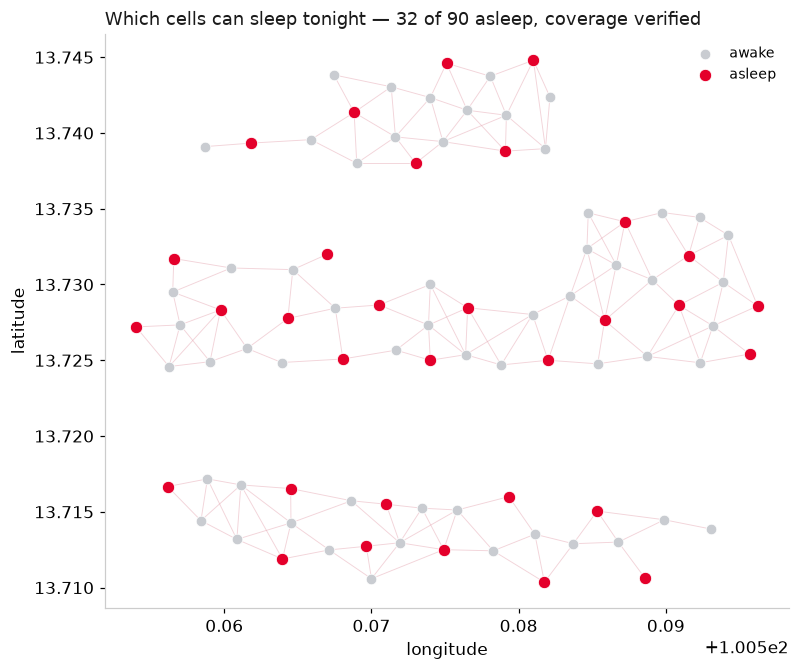

In [13]:
viz.payoff_map(instH, bestH)

### The value — ฿30–75M a year, on True's own constants

<img src="slides/slide-12-value.png" style="width:100%;height:auto;display:block;border-radius:8px;box-shadow:0 1px 12px rgba(0,0,0,0.32);margin:0.6em 0;" alt="slide-12-value.png" />

In [14]:
sc.print_money(len(bestH), HEADLINE_ATOMS)

MONEY MODEL
  energy saved per sleeping site per night : 4.0kW × 60% radio × 70% deep-sleep × 6h = 10.1 kWh
  this district (32 asleep)     : 118 MWh/yr · ฿0.55M/yr · 53 tCO2e/yr

NATIONAL SENSITIVITY — extra cells slept vs per-cell rules (extrapolation printed):
  (district 90 sites -> national 17,000 sites, factor ×189)
     +10 pts :  ฿   29 M/yr     6,255 MWh/yr    2,815 tCO2e/yr
     +15 pts :  ฿   44 M/yr     9,382 MWh/yr    4,222 tCO2e/yr
     +25 pts :  ฿   73 M/yr    15,637 MWh/yr    7,036 tCO2e/yr

Every baht of this is reachable TODAY with a classical solver. Quantum's
contribution to this number in 2026 is ZERO. The reason to run it on quantum
hardware is to measure the gap — see the next section.


## 10 · RESULT 2 — the honest scoreboard

<img src="slides/slide-10-scoreboard.png" style="width:100%;height:auto;display:block;border-radius:8px;box-shadow:0 1px 12px rgba(0,0,0,0.32);margin:0.6em 0;" alt="slide-10-scoreboard.png" />

<img src="slides/slide-11-gap.png" style="width:100%;height:auto;display:block;border-radius:8px;box-shadow:0 1px 12px rgba(0,0,0,0.32);margin:0.6em 0;" alt="slide-11-gap.png" />

In [15]:
# Classical exact-solve scaling on the densest sub-districts.
print("CLASSICAL EXACT SOLVE (max_weight_clique on the complement, commodity CPU):")
print(f"  {'sites':>6s}{'avg deg':>9s}{'exact MIS':>11s}{'wall-clock':>13s}")
scale_pts = []
for k in [30, 60, 90, atoms.n]:
    if k > atoms.n:
        continue
    subk = sc.select_densest(atoms, k)
    Gk = sc.build_graph_from_register(sc.affine_to_atoms(subk))
    s_k, dt_k, done = sc.exact_mis(Gk, timeout_s=30)
    scale_pts.append((k, dt_k, done))
    tag = "" if done else "  (did not finish — reportable!)"
    print(f"  {k:>6d}{2*Gk.number_of_edges()/k:>9.1f}{(len(s_k) if s_k else 0):>11d}{dt_k:>11.3f}s{tag}")
print(f"\n  Aquila, {HEADLINE_ATOMS} atoms : one 4 µs sweep — but throughput is throttled by the shot rate.")
print(f"  approximation ratio (quantum {len(bestH)} / classical optimum {exactH}) = "
      f"{len(bestH)/exactH:.2f}   ← the honest headline metric")

CLASSICAL EXACT SOLVE (max_weight_clique on the complement, commodity CPU):
   sites  avg deg  exact MIS   wall-clock
      30      3.3         14      0.001s
      60      3.8         25      0.010s


      90      3.9         35      0.066s


     116      4.1         46      0.117s



  Aquila, 90 atoms : one 4 µs sweep — but throughput is throttled by the shot rate.
  approximation ratio (quantum 32 / classical optimum 35) = 0.91   ← the honest headline metric


The missing number is not qubits — it is SHOT RATE. The 4 µs sweep is flat in
problem size, but a useful answer needs ~1000 shots; at Aquila's few-Hz effective
rate that is ~200 s (queue excluded), so the flat red line sits ABOVE
classical for these sizes. Going few-Hz -> kHz drops it ~100-1000x — that is where
advantage hides, and the crossover is far to the right.


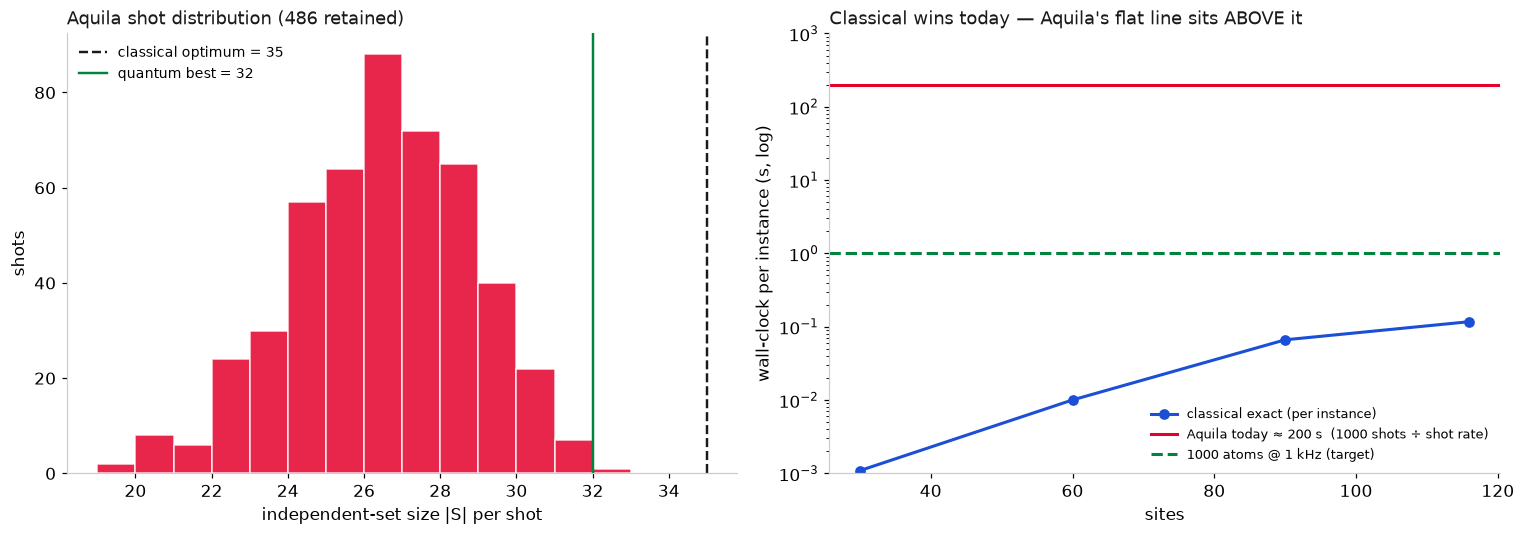

In [16]:
AQUILA_REP_HZ = 5.0                     # ASSUMPTION: Aquila effective rate ~few Hz (load+evolve+image)
aquila_today_s = 1000 / AQUILA_REP_HZ   # one 1000-shot task, shot-rate limited (queue excluded)
future_s = 1000 / 1000.0                # 1000 shots at 1 kHz — Cazals et al. advantage regime
print("The missing number is not qubits — it is SHOT RATE. The 4 µs sweep is flat in")
print("problem size, but a useful answer needs ~1000 shots; at Aquila's few-Hz effective")
print(f"rate that is ~{aquila_today_s:.0f} s (queue excluded), so the flat red line sits ABOVE")
print("classical for these sizes. Going few-Hz -> kHz drops it ~100-1000x — that is where")
print("advantage hides, and the crossover is far to the right.")

viz.scoreboard(sizesH, exactH, len(bestH), scale_pts, aquila_today_s, future_s, retained=retH)

## 11 · Collect the live job

In [17]:
collected, coll_source = None, None
try:
    if SUBMIT_LIVE_JOB and live_job is not None:
        status = str(getattr(live_job, "status", lambda: "UNKNOWN")())
        print(f"live task {live_task_id} status: {status}")
        if "COMPLETED" in status.upper() or "DONE" in status.upper():
            r = live_job.result()
            collected = [sc.Shot(m.pre_sequence, m.post_sequence) for m in r.measurements]
            coll_source = "LIVE QPU (Aquila, Boston)"
        else:
            print("still queued — falling back to the committed result (no exception).")
    else:
        print("using the committed local-simulator result.")
except Exception as e:
    print("collection unavailable — falling back to the committed result:", repr(e)[:100])

if collected is None:
    rr = sc.load_results(f"{RESULTS_DIR}/localsim_{LIVE_ATOMS}_results.json")
    collected = rr["shots"]; coll_source = f"{rr['source']} (committed)"

sel_c, ret_c, tot_c, _ = sc.decode_shots(collected, live_inst["n_atoms"])
best_c = max(sel_c, key=len)
is_qpu = coll_source.startswith("LIVE QPU")
label = "Aquila (Boston)" if is_qpu else "the committed result"
print(f"\nsource           : {coll_source}")
print(f"best sleep set   : |S| = {len(best_c)}  (Cell-7 simulator got {len(sim_best)}, "
      f"exact optimum {exact_live})")
print(f"coverage check   : {'COVERAGE VERIFIED' if sc.verify_independent_set(live_G, best_c) else 'FAILED'}")
agree = "AGREE" if len(best_c) == len(sim_best) else f"differ by {abs(len(best_c)-len(sim_best))}"
print(f"agreement        : {label} and the live-cell simulator {agree} on the sleep-set size")

using the committed local-simulator result.

source           : LOCAL_AHS_SIM (committed)
best sleep set   : |S| = 7  (Cell-7 simulator got 7, exact optimum 7)
coverage check   : COVERAGE VERIFIED
agreement        : the committed result and the live-cell simulator AGREE on the sleep-set size


## 12 · WHAT THIS MEANS

<img src="slides/slide-14-path-forward.png" style="width:100%;height:auto;display:block;border-radius:8px;box-shadow:0 1px 12px rgba(0,0,0,0.32);margin:0.6em 0;" alt="slide-14-path-forward.png" />

### References (cited inline)
- Ebadi et al., *Quantum optimization of maximum independent set using Rydberg atom arrays*, **Science 376, 1209 (2022)**
- Andrist et al., *Hardness of MIS on unit-disk graphs and prospects for quantum speedups*, **Phys. Rev. Research 5, 043277 (2023)**
- Cazals et al., **Phys. Rev. Applied (2026)** — ~1000 atoms at 1 kHz needed for advantage
- Sarkar et al., **arXiv:2511.09633** — Aquila blockade / device parameters
- 3GPP **TS 38.300 §15.4** — Network Energy Savings, cell DTX/DRX
- AWS Braket developer guide — *Submit an analog program using QuEra Aquila*
- Cell-tower data © **OpenCelliD** contributors, **CC-BY-SA 4.0**